In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/SMSSpamCollection', sep='\t', header=None, names=['label', 'message'])
print(df.shape)
print(df['label'].value_counts())
df.head()

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


87% ham / 13% spam in dataset as confirmed bia value_counts(). However, accuracy could be misleading so I'll evaluate with precision/recall/F1.

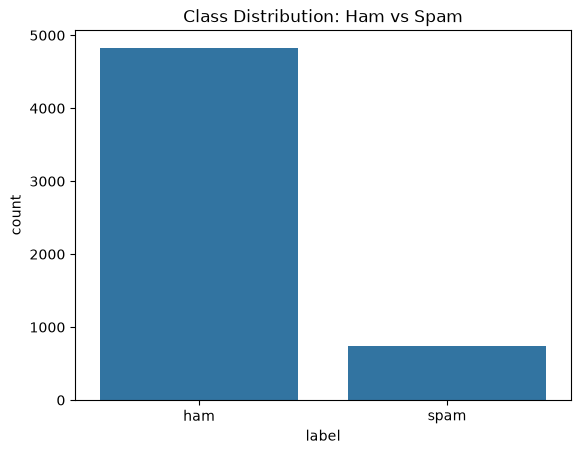

In [7]:
import seaborn as sb

plot = sb.countplot(data=df,x="label").set_title("Class Distribution: Ham vs Spam")

Checking difference in message length between spam and ham.

In [ ]:
df["length"] = df["message"].str.len()

df.groupby('label')['length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.482487,58.440652,2.0,33.0,52.0,93.0,910.0
spam,747.0,138.670683,28.873603,13.0,133.0,149.0,157.0,223.0


Mean length of ham is 71 characters compared to mean length of spam being 139 though evidently more variable as standard deviation of ham is 58 whereas that of spam is only 29. However, 75% of ham is shorter than 93 characters while 75% of spam is longer than 13 characters so length can be a strong separator.

<Axes: xlabel='length', ylabel='Count'>

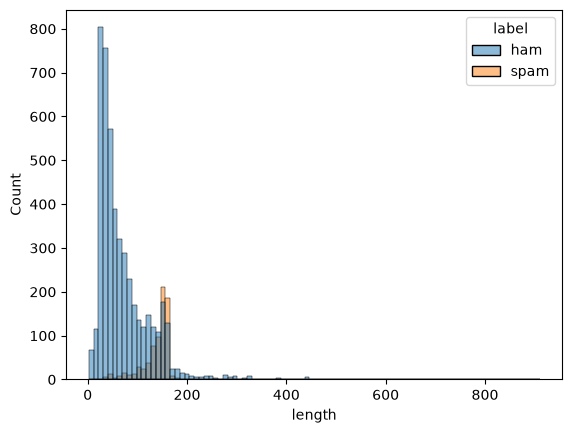

In [18]:
sb.histplot(data=df, x="length", hue="label")

Histogram confirms general difference in length. Ham is mostly under 100 characters while spam is concentrated to be around 130-160 characters.

In [22]:
print(df.duplicated().sum())
print(df.duplicated(subset="message").sum())

403
403


403 duplicate rows. Will remove at preprocessing to prevent train/test leakage.

In [40]:
from collections import Counter

spam = df[df["label"] == "spam"]["message"]
spam_words = " ".join(spam.str.lower()).split()
Counter(spam_words).most_common(20)

[('to', 685),
 ('a', 375),
 ('call', 342),
 ('your', 263),
 ('you', 252),
 ('the', 204),
 ('for', 202),
 ('or', 188),
 ('free', 180),
 ('2', 169),
 ('is', 152),
 ('ur', 144),
 ('on', 142),
 ('txt', 136),
 ('have', 135),
 ('from', 127),
 ('and', 122),
 ('u', 117),
 ('text', 112),
 ('mobile', 109)]

In [39]:
ham = df[df["label"] == "ham"]["message"]
ham_words = " ".join(ham.str.lower()).split()
Counter(ham_words).most_common(20)

[('i', 2181),
 ('you', 1669),
 ('to', 1552),
 ('the', 1125),
 ('a', 1058),
 ('u', 881),
 ('and', 846),
 ('in', 790),
 ('my', 745),
 ('is', 717),
 ('me', 590),
 ('of', 519),
 ('for', 502),
 ('that', 444),
 ('it', 441),
 ('have', 436),
 ('but', 415),
 ('your', 414),
 ('are', 407),
 ('so', 399)]

In [43]:
df["has_digit"] = df["message"].str.contains(r"\d")
df.groupby("label")["has_digit"].mean()

label
ham     0.156477
spam    0.947791
Name: has_digit, dtype: float64

95% of spam contains digits vs 16% of ham. Digit presence is a strong feature.

In [44]:
df["has_currency"] = df["message"].str.contains(r"[£$]")
df.groupby("label")["has_currency"].mean()

label
ham     0.003938
spam    0.344043
Name: has_currency, dtype: float64

About one third of spam contains currency symbol but less than 1% of ham contains currency symbol. Currency presence is a strong feature to determine if message is spam.

In [45]:
df["cap_count"] = df["message"].str.count(r"[A-Z]")
df.groupby("label")["cap_count"].mean()

label
ham      4.099275
spam    15.469880
Name: cap_count, dtype: float64

15 capitalized letters in spam on average compared to 4 in ham.